In [28]:
# Import 

import pandas as pd

# read csv without columns
huzasok = pd.read_csv("otos.csv", sep=";", header=None, 
                      names=["year", "week", "date", "fives", "fives_prize", "fours", "fours_prize", "threes", "threes_prize", "twos", "twos_prize", "n1", "n2", "n3", "n4", "n5"])
display(huzasok)

# szelvények árai időben
szelo_arak = {'elotte': 130,
              '2003.04.': 150,
              '2005.03.': 175,
              '2007.11.': 200,
              '2010.02.': 225,
              '2016.11.': 250,
              '2020.01.': 300,
              '2022.10.': 350,
              '2023.09.': 400
              } # mikortól mennyi lett az ára


,year,week,date,fives,fives_prize,fours,fours_prize,threes,threes_prize,twos,twos_prize,n1,n2,n3,n4,n5
0,2025,47,2025.11.22.,0,0 Ft,18,2 654 765 Ft,1817,27 685 Ft,53672,3 515 Ft,16,22,37,74,81
1,2025,46,2025.11.15.,0,0 Ft,48,1 023 290 Ft,2024,25 545 Ft,51808,3 740 Ft,26,46,55,64,66
2,2025,45,2025.11.08.,0,0 Ft,69,693 450 Ft,3686,13 665 Ft,75108,2 515 Ft,6,12,24,30,79
3,2025,44,2025.11.01.,0,0 Ft,21,2 135 390 Ft,2521,18 725 Ft,67076,2 640 Ft,11,20,29,42,55
4,2025,43,2025.10.25.,0,0 Ft,27,1 658 575 Ft,1762,26 755 Ft,52614,3 360 Ft,12,30,49,51,66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3581,1957,14,NaN,0,0 Ft,0,0 Ft,0,0 Ft,0,0 Ft,26,33,38,47,53
3582,1957,13,NaN,0,0 Ft,0,0 Ft,0,0 Ft,0,0 Ft,7,9,19,42,66
3583,1957,12,NaN,0,0 Ft,0,0 Ft,0,0 Ft,0,0 Ft,8,12,24,26,85
3584,1957,11,NaN,0,0 Ft,0,0 Ft,0,0 Ft,0,0 Ft,1,49,64,67,71


    number     popularity
0        4  353133.542857
1        3  350988.542857
2       13  331840.028571
3       55  329866.628571
4       27  323897.428571
5       15  315217.228571
6        1  310042.857143
7       18  296772.485714
8       19  292420.628571
9       59  288746.771429
10      24  285191.085714
11      25  285117.000000
12      17  283849.685714
13      12  281145.742857
14      11  280923.571429
15       7  279001.171429
16      28  278802.000000
17      37  277767.828571
18       2  274876.457143
19      42  269965.342857


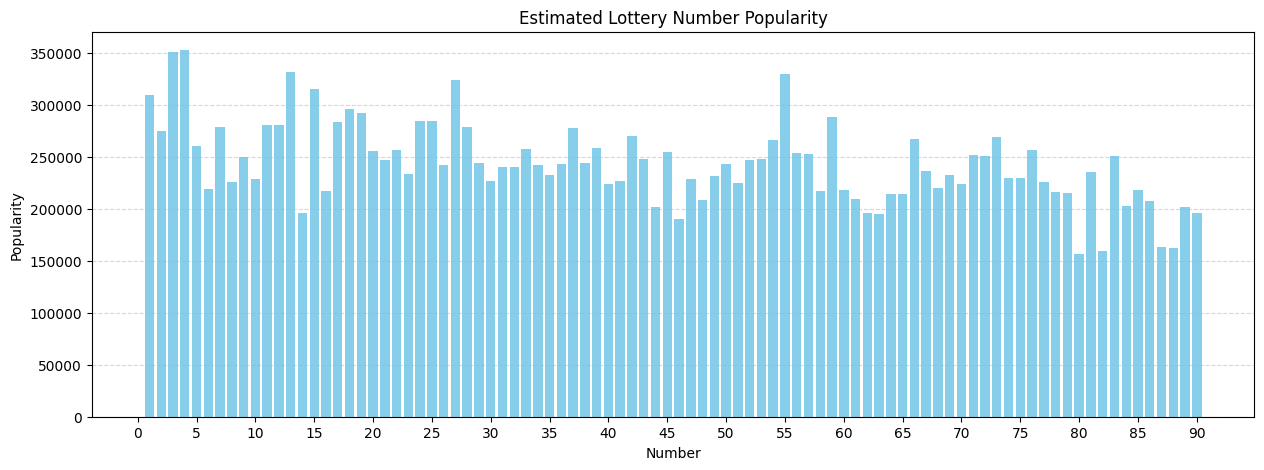

In [45]:
# Népszerű számok

import pandas as pd
from collections import defaultdict

# feltételezzük: huzasok már be van olvasva

# --- SEGÉDFÜGGVÉNY ---
def to_int_prize(x):
    """ '2 654 765 Ft' → 2654765 (opcionális) """
    if isinstance(x, str):
        return int(x.replace(" ", "").replace("Ft", ""))
    return 0

# --- NÉPSZERŰSÉG BECSLÉS (új súlyokkal) ---

# súlyok
w_twos = 1/7
w_threes = 2/7
w_fours = 4/7

popularity = defaultdict(float)

# csak a valid sorok
valid = huzasok.dropna(subset=["twos", "threes", "fours"])

for _, row in valid.iterrows():
    
    # számítsuk az egy számra jutó arányt (arányalapú becslés)
    score_twos   = (row["twos"] / 5) * w_twos
    score_threes = (row["threes"] / 5) * w_threes
    score_fours  = (row["fours"] / 5) * w_fours

    # kombinált népszerűségi érték
    draw_popularity = score_twos + score_threes + score_fours

    # minden kihúzott számhoz hozzáadjuk
    for n in [row["n1"], row["n2"], row["n3"], row["n4"], row["n5"]]:
        popularity[n] += draw_popularity

# --- EREDMÉNY: számonkénti népszerűségi táblázat ---
popularity_df = (
    pd.DataFrame({"number": range(1, 91)})
      .assign(popularity=lambda df: df["number"].map(popularity))
      .fillna(0)
      .sort_values("popularity", ascending=False)
      .reset_index(drop=True)
)

print(popularity_df.head(20))

import matplotlib.pyplot as plt

# Barplot
plt.figure(figsize=(15,5))
plt.bar(popularity_df["number"], popularity_df["popularity"], color="skyblue")
plt.xlabel("Number")
plt.ylabel("Popularity")
plt.title("Estimated Lottery Number Popularity")
plt.xticks(range(0, 91, 5))  # x-tengely címkék 5-ös lépésben
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()



    number  count  relative_freq
0        3    239       0.066648
1       15    229       0.063859
2       77    226       0.063023
3       75    226       0.063023
4       29    226       0.063023
5        1    223       0.062186
6       42    221       0.061629
7       13    220       0.061350
8       55    220       0.061350
9        4    219       0.061071
10      86    219       0.061071
11      12    218       0.060792
12      56    217       0.060513
13      66    215       0.059955
14      10    214       0.059677
15      47    214       0.059677
16      76    213       0.059398
17      72    213       0.059398
18      51    212       0.059119
19       7    211       0.058840


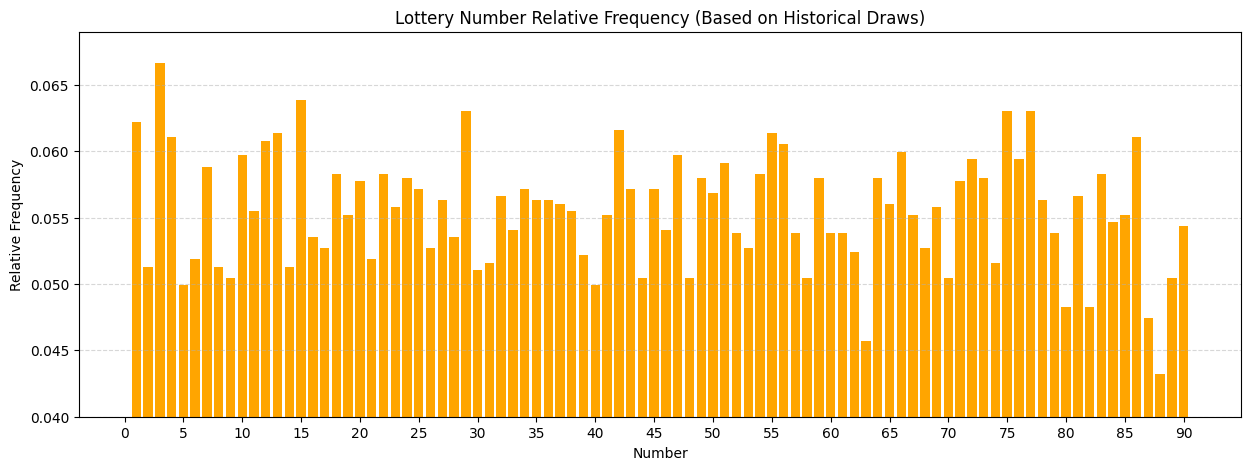

In [46]:
# Hideg/meleg számok

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# feltételezzük, hogy 'valid' már létezik a korábbi kódból
# minden húzásban az öt szám szerepel: n1-n5

# --- 1️⃣ Összesítés ---
numbers = []
for _, row in valid.iterrows():
    numbers.extend([row["n1"], row["n2"], row["n3"], row["n4"], row["n5"]])

counts = Counter(numbers)

# --- 2️⃣ Relatív gyakoriság ---
total_draws = len(valid)  # húzások száma
relative_freq = {num: counts[num]/total_draws for num in range(1,91)}

# --- 3️⃣ DataFrame készítése ---
freq_df = pd.DataFrame({
    "number": range(1,91),
    "count": [counts.get(num,0) for num in range(1,91)],
    "relative_freq": [relative_freq.get(num,0) for num in range(1,91)]
}).sort_values("count", ascending=False).reset_index(drop=True)

print(freq_df.head(20))

# --- 4️⃣ Barplot vizualizáció ---
plt.figure(figsize=(15,5))
plt.bar(freq_df["number"], freq_df["relative_freq"], color="orange")
plt.xlabel("Number")
plt.ylabel("Relative Frequency")
plt.title("Lottery Number Relative Frequency (Based on Historical Draws)")
plt.xticks(range(0,91,5))
plt.ylim(0.04, 0.069)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


In [51]:
import pandas as pd

# feltételezzük, hogy 'valid' már létezik

# szelvényárak
szelo_arak = {
    'elotte': 130,
    '2003.04.': 150,
    '2005.03.': 175,
    '2007.11.': 200,
    '2010.02.': 225,
    '2016.11.': 250,
    '2020.01.': 300,
    '2022.10.': 350,
    '2023.09.': 400
}

# --- SEGÉDFÜGGVÉNY: dátum alapján ár kiválasztása ---
def get_ticket_price(date_str):
    date_str = date_str.rstrip('.')  # eltávolítjuk a pontot
    prev_key = 'elotte'
    for key in sorted(szelo_arak.keys()):
        if key == 'elotte':
            continue
        if date_str < key:
            return szelo_arak[prev_key]
        prev_key = key
    return szelo_arak[prev_key] if 'prev_key' in locals() else szelo_arak['elotte']

# --- Húzásonkénti összesítés --- 
summary = []

for _, row in valid.iterrows():
    price = get_ticket_price(row['date'])
    
    # kategóriák: nyertes szelvények és nyeremények
    categories = ['twos', 'threes', 'fours', 'fives']
    prize_columns = ['twos_prize', 'threes_prize', 'fours_prize', 'fives_prize']
    
    total_winners = 0
    total_prize = 0
    breakdown = {}  # bontás kategóriánként
    
    for cat, prize_col in zip(categories, prize_columns):
        winners = row[cat] if pd.notnull(row[cat]) else 0
        try:
            prize = int(str(row[prize_col]).replace(' ','').replace('Ft',''))
        except:
            prize = 0
        cat_total_prize = winners * prize
        breakdown[cat+'_prize'] = cat_total_prize
        total_winners += winners
        total_prize += cat_total_prize
    
    total_cost = total_winners * price
    relative_payout = total_prize / total_cost if total_cost > 0 else 0
    
    summary.append({
        'year': row['year'],
        'week': row['week'],
        'date': row['date'],
        'total_winners': total_winners,
        'total_prize': total_prize/1_000_000,
        'total_cost': total_cost/1_000_000,
        'relative_payout': relative_payout,
        'fives_prize': breakdown.get('fives_prize',0)/1_000_000,
        'fours_prize': breakdown.get('fours_prize',0)/1_000_000,
        'threes_prize': breakdown.get('threes_prize',0)/1_000_000,
        'twos_prize': breakdown.get('twos_prize',0)/1_000_000
    })

summary_df = pd.DataFrame(summary)

# rendezhetjük időrendbe
summary_df = summary_df.sort_values(['year','week']).reset_index(drop=True)

print(summary_df.head(20))


    year  week         date  total_winners  total_prize  total_cost  \
0   2004    45  2004.11.06.          91268   184.205358   13.690200   
1   2004    46  2004.11.13.         108962   202.655178   16.344300   
2   2004    47  2004.11.20.         123771   187.839521   18.565650   
3   2004    48  2004.11.27.          97628   192.749051   14.644200   
4   2004    49  2004.12.04.         171688   204.496768   25.753200   
5   2004    50  2004.12.11.          85917   255.972754   12.887550   
6   2004    51  2004.12.18.         147404   218.176244   22.110600   
7   2004    52  2004.12.25.         137036   218.222702   20.555400   
8   2004    53  2005.01.01.         149488   242.700166   22.423200   
9   2005     1  2005.01.08.         125806   315.879795   18.870900   
10  2005     2  2005.01.15.         149504   282.965486   22.425600   
11  2005     3  2005.01.22.         152755   289.419781   22.913250   
12  2005     4  2005.01.29.         208055  1658.735551   31.208250   
13  20

In [56]:
ratios = pd.DataFrame({'fives/twos': summary_df['fives_prize'] / summary_df['twos_prize'],
                       'fours/twos': summary_df['fours_prize'] / summary_df['twos_prize'],
                       'threes/twos': summary_df['threes_prize'] / summary_df['twos_prize']
                       })
display(ratios.describe())
print()
display(ratios[ratios['fives/twos'] != 0].describe())

# minden esetben 4/2: 0.485 és 3/2: 0.514

,fives/twos,fours/twos,threes/twos
count,1099.000000,1099.000000,1099.000000
mean,0.785591,0.425507,0.451879
std,3.167803,0.083085,0.087075
min,0.000000,0.240515,0.252902
25%,0.000000,0.357148,0.384115
50%,0.000000,0.485044,0.513550
75%,0.000000,0.485824,0.514398
max,29.204939,0.487192,0.515866


,fives/twos,fours/twos,threes/twos
count,95.000000,95.000000,95.000000
mean,9.088047,0.435082,0.462132
std,6.400096,0.077738,0.080806
min,0.855388,0.241264,0.259607
25%,3.384319,0.361842,0.386950
50%,8.139950,0.485189,0.513797
75%,13.169428,0.485932,0.514513
max,29.204939,0.487036,0.515741
